## **Task 1: Get the Stock Data**

In [ ]:
# Step 1 : Install yfinance
!pip install yfinance

In [ ]:
# Step 2 : Download the data
import yfinance as yf
import pandas as pd

# Our 5 assets
assets = ['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS']

# Dictionary to hold each asset's dataframe
stock_data = {}

for ticker in assets:
    print(f"Downloading {ticker}...")
    df = yf.download(ticker, period='5y')
    stock_data[ticker] = df
    df.to_csv(f'data_{ticker}.csv')

print("Done! Downloaded:", list(stock_data.keys()))

/tmp/ipykernel_2049/4123439539.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='5y')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2049/4123439539.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='5y')


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2049/4123439539.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='5y')


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2049/4123439539.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='5y')


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2049/4123439539.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='5y')


[*********************100%***********************]  1 of 1 completed

Done! Downloaded: ['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS']


In [ ]:
# Step 3 : Checking
stock_data['RELIANCE.NS'].head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-07-26,940.642578,960.638870,938.038299,954.750983,12389668
2021-07-27,930.746338,943.745093,924.858451,940.619982,10824523
2021-07-28,922.752319,932.105071,913.195727,932.105071,12897848
2021-07-29,929.953674,939.532908,925.492430,930.293368,13765738
2021-07-30,921.823792,936.611523,919.921482,932.104995,11350608


## **Task 2: Get the News Data**

In [ ]:
# Step 1 : Write the fetch function
import requests
import pandas as pd
import time

API_KEY = "your_newsapi_key_here"

def fetch_news(company_name):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": company_name,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": 100,
        "apiKey": API_KEY
    }
    response = requests.get(url, params=params)
    data = response.json()

    if data.get("status") != "ok":
        print(f"Error fetching {company_name}: {data.get('message')}")
        return []

    return data.get("articles", [])

In [ ]:
# Step 2 : Fetch news for all 5 assets and save
company_names = {
    '^BSESN': 'Sensex',
    'RELIANCE.NS': 'Reliance Industries',
    'TCS.NS': 'TCS',
    'INFY.NS': 'Infosys',
    'HDFCBANK.NS': 'HDFC Bank'
}

all_news = []

for ticker, name in company_names.items():
    articles = fetch_news(name)
    for article in articles:
        all_news.append({
            "ticker": ticker,
            "company": name,
            "title": article.get("title"),
            "description": article.get("description"),
            "publishedAt": article.get("publishedAt"),
            "source": article.get("source", {}).get("name")
        })
    time.sleep(1)  # be polite to the free tier's rate limit

news_df = pd.DataFrame(all_news)
news_df.to_csv("news_data.csv", index=False)
print(f"Saved {len(news_df)} articles.")

Saved 498 articles.


In [ ]:
news_df.head()
news_df['company'].value_counts()

,count
company,
Reliance Industries,100
Infosys,100
TCS,100
HDFC Bank,100
Sensex,98


## **Task 3: Clean the Data**

In [ ]:
# Step 1 : Check for missing values
for ticker, df in stock_data.items():
    print(f"{ticker}: {df.isnull().sum().sum()} missing values")

^BSESN: 0 missing values
RELIANCE.NS: 0 missing values
TCS.NS: 0 missing values
INFY.NS: 0 missing values
HDFCBANK.NS: 0 missing values


In [ ]:
# Step 2 : Flatten MultiIndex columns
for ticker, df in stock_data.items():
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    stock_data[ticker] = df

# checking
stock_data['RELIANCE.NS'].columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
# Step 3 : Fix data types and handle any missing values
for ticker, df in stock_data.items():
    df.index = pd.to_datetime(df.index)   # ensure the date index is a real datetime
    df = df.ffill()                       # forward-fill: carry last known price forward for any gap
    df = df.dropna()                      # drop any remaining rows that are still empty
    stock_data[ticker] = df

In [ ]:
# Step 4 : Clean the news data
news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
news_df = news_df.dropna(subset=['title', 'description'])  # drop articles with no real text
news_df = news_df.drop_duplicates(subset=['title'])          # remove duplicate headlines
print(f"News data after cleaning: {len(news_df)} articles")

News data after cleaning: 340 articles


In [ ]:
# Step 5 : Verify everything looks right
stock_data['RELIANCE.NS'].info()
news_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1239 entries, 2021-07-26 to 2026-07-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1239 non-null   float64
 1   High    1239 non-null   float64
 2   Low     1239 non-null   float64
 3   Open    1239 non-null   float64
 4   Volume  1239 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.1 KB
<class 'pandas.core.frame.DataFrame'>
Index: 340 entries, 0 to 492
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   ticker       340 non-null    object             
 1   company      340 non-null    object             
 2   title        340 non-null    object             
 3   description  340 non-null    object             
 4   publishedAt  340 non-null    datetime64[ns, UTC]
 5   source       340 non-null    object             
dtypes: datetime64[ns, UTC](1), obj

## **Task 4: EDA**

In [ ]:
# Step 1 : Price trend for each asset
import plotly.express as px

for ticker, df in stock_data.items():
    fig = px.line(df, x=df.index, y='Close', title=f'{ticker} Price Trend')
    fig.show()

In [ ]:
# Step 2 : Distribution of daily returns

for ticker, df in stock_data.items():
    df['daily_return'] = df['Close'].pct_change() * 100
    fig = px.histogram(df, x='daily_return', title=f'{ticker} Daily Return Distribution', nbins=50)
    fig.show()

In [ ]:
# Step 3 : Volume trend

for ticker, df in stock_data.items():
    fig = px.line(df, x=df.index, y='Volume', title=f'{ticker} Volume Trend')
    fig.show()

In [ ]:
# Step 4 : Correlation heatmap

import pandas as pd

close_prices = pd.DataFrame({ticker: df['Close'] for ticker, df in stock_data.items()})
correlation = close_prices.corr()

fig = px.imshow(correlation, text_auto=True, title='Correlation Between Assets', color_continuous_scale='RdBu_r')
fig.show()

In [ ]:
# Step 5 : Summary statistics table

for ticker, df in stock_data.items():
    print(f"\n{ticker} summary:")
    print(df[['Close', 'Volume', 'daily_return']].describe())


^BSESN summary:
Price         Close         Volume  daily_return
count   1233.000000    1233.000000   1232.000000
mean   69745.335076   12250.851582      0.033393
std    10149.215922   15431.899034      0.876128
min    51360.421875       0.000000     -5.740558
25%    59919.691406    7100.000000     -0.431892
50%    71721.179688    9500.000000      0.046119
75%    79705.906250   13600.000000      0.528204
max    85836.117188  452000.000000      3.948614

RELIANCE.NS summary:
Price        Close        Volume  daily_return
count  1239.000000  1.239000e+03   1238.000000
mean   1264.949453  1.334738e+07      0.034654
std     150.797293  6.808520e+06      1.407718
min     921.823792  0.000000e+00     -7.485140
25%    1143.275452  8.909261e+06     -0.797671
50%    1242.321411  1.181730e+07      0.035118
75%    1401.981812  1.610998e+07      0.778487
max    1584.971802  8.199715e+07      7.019192

TCS.NS summary:
Price        Close        Volume  daily_return
count  1239.000000  1.239000e+03 

## **Task 5: Feature Engineering**

In [ ]:
# Step 1 : Price-based features

import numpy as np

for ticker, df in stock_data.items():
    df['daily_return'] = df['Close'].pct_change() * 100
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['high_low_ratio'] = df['High'] / df['Low']
    stock_data[ticker] = df

In [ ]:
# Step 2 : Trend features (moving averages)

for ticker, df in stock_data.items():
    df['ma_7'] = df['Close'].rolling(7).mean()
    df['ma_14'] = df['Close'].rolling(14).mean()
    df['ma_30'] = df['Close'].rolling(30).mean()
    df['price_to_ma7'] = df['Close'] / df['ma_7']
    df['ma_crossover'] = (df['ma_7'] > df['ma_14']).astype(int)
    stock_data[ticker] = df

In [ ]:
# Step 3 : Volatility features

for ticker, df in stock_data.items():
    df['volatility_7'] = df['daily_return'].rolling(7).std()
    df['volatility_14'] = df['daily_return'].rolling(14).std()
    stock_data[ticker] = df

In [ ]:
# Step 4 : Time features

for ticker, df in stock_data.items():
    df['day_of_week'] = df.index.dayofweek   # Monday=0 ... Sunday=6
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_monday'] = (df['day_of_week'] == 0).astype(int)
    df['is_friday'] = (df['day_of_week'] == 4).astype(int)
    stock_data[ticker] = df

In [ ]:
# Step 5 : Volume features

for ticker, df in stock_data.items():
    df['volume_ma_7'] = df['Volume'].rolling(7).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_ma_7']
    stock_data[ticker] = df

In [ ]:
# Step 6 : Create the target (what we're actually predicting)

for ticker, df in stock_data.items():
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)   # 1 = tomorrow UP, 0 = DOWN
    stock_data[ticker] = df

In [ ]:
# Step 7 — Drop the rows that now have NaNs

for ticker, df in stock_data.items():
    df = df.dropna()
    stock_data[ticker] = df
    print(f"{ticker}: {df.shape[0]} rows, {df.shape[1]} columns after feature engineering")

^BSESN: 1204 rows, 23 columns after feature engineering
RELIANCE.NS: 1210 rows, 23 columns after feature engineering
TCS.NS: 1210 rows, 23 columns after feature engineering
INFY.NS: 1210 rows, 23 columns after feature engineering
HDFCBANK.NS: 1210 rows, 23 columns after feature engineering


## **Task 6: Build Model for a Single Asset**

In [ ]:
# Step 1 : Pick the feature columns

feature_cols = [
    'daily_return', 'log_return', 'high_low_ratio',
    'ma_7', 'ma_14', 'ma_30', 'price_to_ma7', 'ma_crossover',
    'volatility_7', 'volatility_14',
    'day_of_week', 'month', 'quarter', 'is_monday', 'is_friday',
    'volume_ma_7', 'volume_ratio'
]

In [ ]:
# Step 2 : The time-based split

from sklearn.model_selection import train_test_split

def process_asset(ticker, df, feature_cols, test_size=0.2):
    X = df[feature_cols]
    y = df['target']

    split_index = int(len(df) * (1 - test_size))
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    return X_train, X_test, y_train, y_test

In [ ]:
# Step 3 : Build the pipeline and train
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

def process_asset(ticker, df, feature_cols, test_size=0.2):
    X = df[feature_cols]
    y = df['target']

    split_index = int(len(df) * (1 - test_size))
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    return {
        'model': pipeline,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

In [ ]:
# Step 4 : Test it on one stock first

result = process_asset('RELIANCE.NS', stock_data['RELIANCE.NS'], feature_cols)
print("Test accuracy:", (result['y_pred'] == result['y_test']).mean())

Test accuracy: 0.4380165289256198


In [ ]:
print(result['y_test'].value_counts(normalize=True))

target
0    0.520661
1    0.479339
Name: proportion, dtype: float64


In [ ]:
majority_class = result['y_test'].mode()[0]
baseline_acc = (result['y_test'] == majority_class).mean()
print("Baseline (always predict majority):", baseline_acc)

Baseline (always predict majority): 0.5206611570247934


In [ ]:
from sklearn.ensemble import RandomForestClassifier

configs = [
    {'n_estimators': 100, 'max_depth': 3},
    {'n_estimators': 100, 'max_depth': 4},
    {'n_estimators': 200, 'max_depth': 5},
    {'n_estimators': 300, 'max_depth': None},   # None = trees grow fully, no depth limit
]

X = stock_data['RELIANCE.NS'][feature_cols]
y = stock_data['RELIANCE.NS']['target']
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

for cfg in configs:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=42, **cfg))
    ])
    pipeline.fit(X_train, y_train)
    train_acc = pipeline.score(X_train, y_train)
    test_acc = pipeline.score(X_test, y_test)
    print(f"{cfg} -> train acc: {train_acc:.3f}, test acc: {test_acc:.3f}")

{'n_estimators': 100, 'max_depth': 3} -> train acc: 0.669, test acc: 0.483
{'n_estimators': 100, 'max_depth': 4} -> train acc: 0.754, test acc: 0.467
{'n_estimators': 200, 'max_depth': 5} -> train acc: 0.835, test acc: 0.446
{'n_estimators': 300, 'max_depth': None} -> train acc: 1.000, test acc: 0.479


## **Task 7: Run Model for All Assets**

In [ ]:
# Step 1 : Update the function with the tuned depth
def process_asset(ticker, df, feature_cols, test_size=0.2, max_depth=4, n_estimators=100):
    X = df[feature_cols]
    y = df['target']

    split_index = int(len(df) * (1 - test_size))
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    return {
        'model': pipeline,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'train_acc': pipeline.score(X_train, y_train),
        'test_acc': pipeline.score(X_test, y_test)
    }

In [ ]:
# Step 2 : Loop over all 5 stocks

results = {}

for ticker, df in stock_data.items():
    print(f"Processing {ticker}...")
    results[ticker] = process_asset(ticker, df, feature_cols)

print("\nDone! Processed:", list(results.keys()))

Processing ^BSESN...
Processing RELIANCE.NS...
Processing TCS.NS...
Processing INFY.NS...
Processing HDFCBANK.NS...

Done! Processed: ['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS']


In [ ]:
# Step 3 : Quick comparison view

for ticker, res in results.items():
    print(f"{ticker}: train acc = {res['train_acc']:.3f}, test acc = {res['test_acc']:.3f}")

^BSESN: train acc = 0.717, test acc = 0.544
RELIANCE.NS: train acc = 0.754, test acc = 0.467
TCS.NS: train acc = 0.733, test acc = 0.488
INFY.NS: train acc = 0.720, test acc = 0.455
HDFCBANK.NS: train acc = 0.694, test acc = 0.397


## **Task 8: Business Metrics**

In [ ]:
# Step 1 : Calculate metrics for each stock
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

metrics_summary = []

for ticker, res in results.items():
    y_test = res['y_test']
    y_pred = res['y_pred']
    y_proba = res['y_proba']

    metrics_summary.append({
        'ticker': ticker,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba)
    })

metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df.round(3)
print(metrics_df)

        ticker  accuracy  precision  recall     f1    auc
0       ^BSESN     0.544      0.542   0.587  0.563  0.548
1  RELIANCE.NS     0.467      0.442   0.431  0.437  0.496
2       TCS.NS     0.488      0.466   0.723  0.566  0.500
3      INFY.NS     0.455      0.424   0.714  0.532  0.439
4  HDFCBANK.NS     0.397      0.349   0.500  0.411  0.427


In [ ]:
# Step 2 : Sort to see which stock the model handles best

metrics_df.sort_values('auc', ascending=False)

,ticker,accuracy,precision,recall,f1,auc
0,^BSESN,0.544,0.542,0.587,0.563,0.548
2,TCS.NS,0.488,0.466,0.723,0.566,0.500
1,RELIANCE.NS,0.467,0.442,0.431,0.437,0.496
3,INFY.NS,0.455,0.424,0.714,0.532,0.439
4,HDFCBANK.NS,0.397,0.349,0.500,0.411,0.427


## **Task 9: Threshold Tuning**

In [ ]:
# Step 1 : Define the cost function

from sklearn.metrics import confusion_matrix

cost_fp = 100   # cost of a false positive: predicted UP, actually DOWN (a bad trade)
cost_fn = 50    # cost of a false negative: predicted DOWN, actually UP (a missed opportunity)

def find_optimal_threshold(y_test, y_proba, cost_fp=100, cost_fn=50):
    thresholds = np.arange(0.1, 0.9, 0.05)
    costs = []

    for thresh in thresholds:
        y_pred_t = (y_proba >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        total_cost = (fp * cost_fp) + (fn * cost_fn)
        costs.append(total_cost)

    costs = np.array(costs)
    optimal_idx = costs.argmin()
    return thresholds[optimal_idx], costs, thresholds

In [ ]:
# Step 2 : Run it for each stock and plot cost vs threshold

for ticker, res in results.items():
    optimal_thresh, costs, thresholds = find_optimal_threshold(res['y_test'], res['y_proba'])

    fig = px.line(x=thresholds, y=costs, title=f'{ticker}: Cost vs Threshold',
                  labels={'x': 'Threshold', 'y': 'Total Cost'})
    fig.add_vline(x=optimal_thresh, line_dash='dash', line_color='red')
    fig.show()

    print(f"{ticker}: optimal threshold = {optimal_thresh:.2f}")

^BSESN: optimal threshold = 0.75


RELIANCE.NS: optimal threshold = 0.60


TCS.NS: optimal threshold = 0.65


INFY.NS: optimal threshold = 0.65


HDFCBANK.NS: optimal threshold = 0.60


In [ ]:
# Step 3 : Compare default (0.5) vs optimal threshold
comparison = []

for ticker, res in results.items():
    optimal_thresh, costs, thresholds = find_optimal_threshold(res['y_test'], res['y_proba'])

    y_pred_default = (res['y_proba'] >= 0.5).astype(int)
    y_pred_optimal = (res['y_proba'] >= optimal_thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(res['y_test'], y_pred_default).ravel()
    cost_default = (fp * cost_fp) + (fn * cost_fn)

    tn, fp, fn, tp = confusion_matrix(res['y_test'], y_pred_optimal).ravel()
    cost_optimal = (fp * cost_fp) + (fn * cost_fn)

    comparison.append({
        'ticker': ticker,
        'default_threshold_cost': cost_default,
        'optimal_threshold': optimal_thresh,
        'optimal_threshold_cost': cost_optimal,
        'savings': cost_default - cost_optimal
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

        ticker  default_threshold_cost  optimal_threshold  \
0       ^BSESN                    8500               0.75   
1  RELIANCE.NS                    9600               0.60   
2       TCS.NS                   10850               0.65   
3      INFY.NS                   11700               0.65   
4  HDFCBANK.NS                   12050               0.60   

   optimal_threshold_cost  savings  
0                    6050     2450  
1                    5800     3800  
2                    5600     5250  
3                    5200     6500  
4                    5100     6950  


## **Task 10: SHAP Explainability**

In [ ]:
# Step 1 : Install SHAP
!pip install shap

In [ ]:
# Step 2 : Create an explainer for one stock (let's use Sensex, since it's your strongest model)

import shap

ticker = '^BSESN'
model_pipeline = results[ticker]['model']
X_test = results[ticker]['X_test']

# Pull just the trained classifier out of the pipeline (SHAP needs the raw model, not the pipeline)
classifier = model_pipeline.named_steps['classifier']

# We also need the scaled version of X_test, since that's what the classifier actually saw
scaler = model_pipeline.named_steps['scaler']
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_scaled_df)

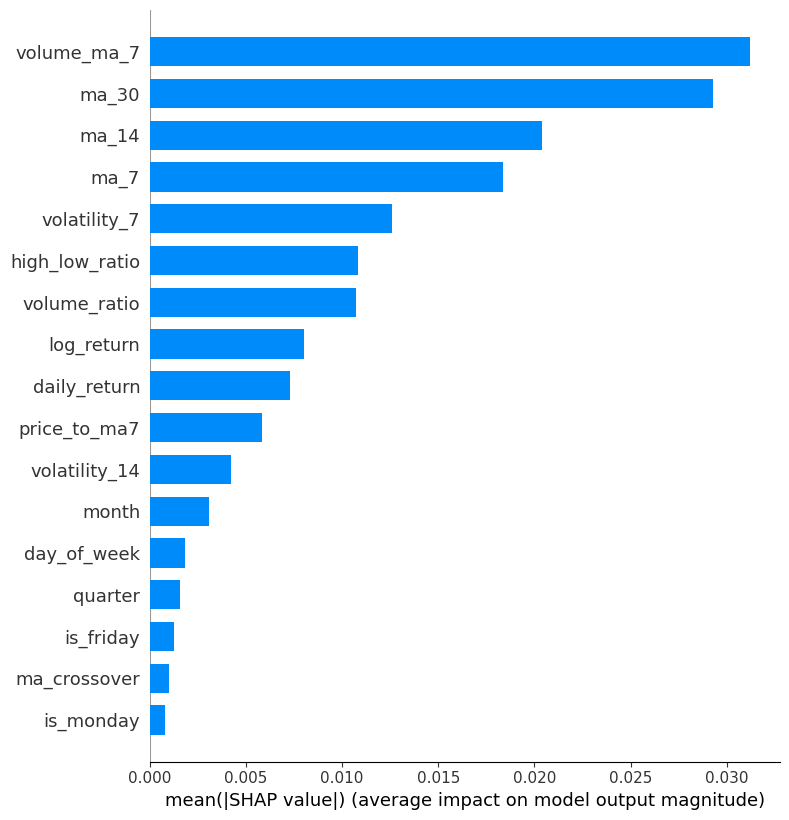

In [ ]:
# Step 3 : Global feature importance (bar chart)
shap.summary_plot(shap_values[:, :, 1], X_test_scaled_df, plot_type="bar")

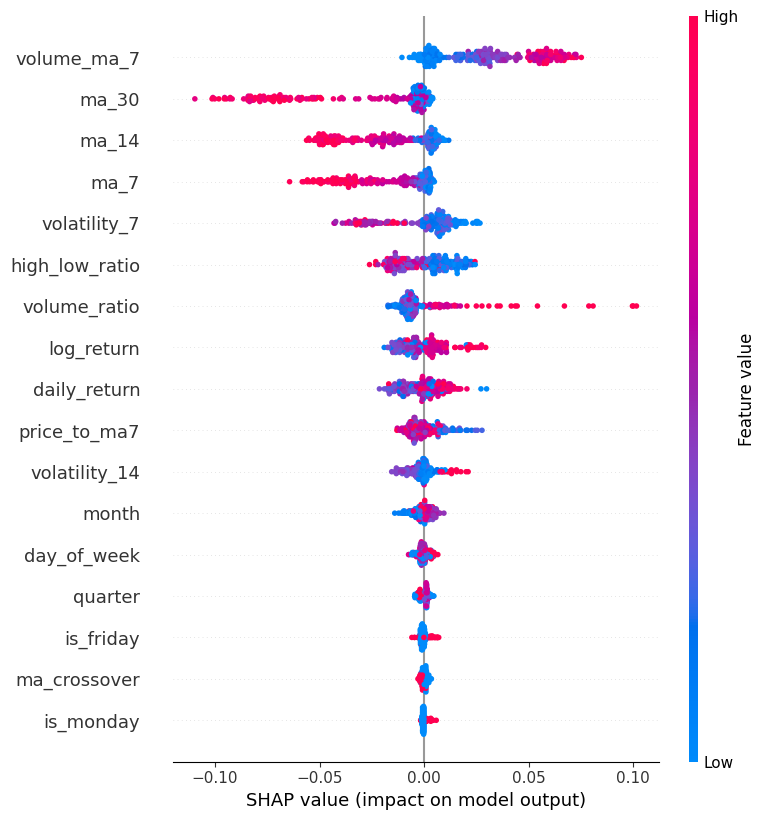

In [ ]:
# Step 4 : Summary dot plot
shap.summary_plot(shap_values[:, :, 1], X_test_scaled_df)

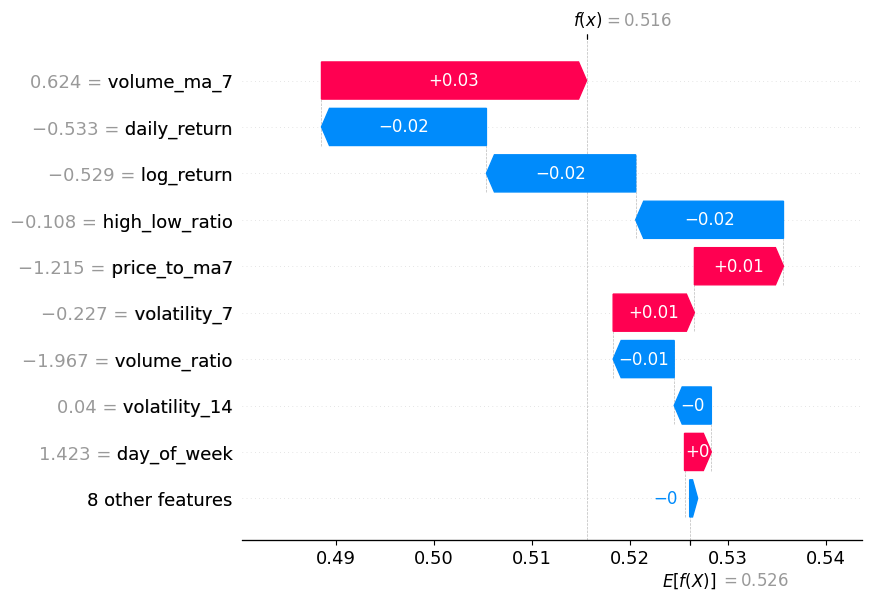

In [ ]:
# Step 5 : Waterfall plot for one specific prediction
# Pick the most recent test-day prediction
sample_idx = -1  # last row in the test set = most recent day

shap.waterfall_plot(shap.Explanation(
    values=shap_values[sample_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_scaled_df.iloc[sample_idx],
    feature_names=X_test_scaled_df.columns.tolist()
))

In [ ]:
# Step 6 : Force plot

shap.initjs()  # needed once per notebook session for force plots to render

shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_idx, :, 1],
    X_test_scaled_df.iloc[sample_idx],
    feature_names=X_test_scaled_df.columns.tolist()
)

## **Task 11: Build the RAG Pipeline**

In [ ]:
# Step 1 : Install the libraries
!pip install sentence-transformers chromadb cohere

In [ ]:
# Step 2 : Prepare the news documents

# Combine title + description into one text block per article — richer content to search over
news_df['full_text'] = news_df['title'].fillna('') + ". " + news_df['description'].fillna('')

# We need a unique ID per article for ChromaDB
news_df = news_df.reset_index(drop=True)
news_df['doc_id'] = news_df.index.astype(str)

documents = news_df['full_text'].tolist()
doc_ids = news_df['doc_id'].tolist()

print(f"Prepared {len(documents)} documents")
print(documents[0])  # sanity check

Prepared 340 documents
Suryoday SFB Q1 profit more than doubles on strong loan growth. Suryoday Small Finance Bank reported a more than twofold rise in first-quarter net profit to Rs 75 crore, driven by healthy business growth. Net interest income, operating profit and advances increased strongly, while gross NPAs improved significantly from a …


In [ ]:
# Step 3 : Create embeddings

from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embed_model.encode(documents, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Embedding shape: (340, 384)


In [ ]:
# Step 4 : Store embeddings in ChromaDB

import chromadb

client = chromadb.Client()
collection = client.get_or_create_collection("news")

# Since we're reusing the collection, clear out old data first so we don't get duplicates
collection.delete(ids=collection.get()['ids'])

collection.add(
    ids=doc_ids,
    embeddings=embeddings.tolist(),
    documents=documents,
    metadatas=news_df[['ticker', 'company', 'publishedAt']].astype(str).to_dict('records')
)

print("Stored", collection.count(), "documents in ChromaDB")

Stored 340 documents in ChromaDB


In [ ]:
# Step 5 : Write the search function

def search_news(query, n_results=3, ticker_filter=None):
    query_embedding = embed_model.encode([query])

    where_clause = {"ticker": ticker_filter} if ticker_filter else None

    results = collection.query(
        query_embeddings=query_embedding.tolist(),
        n_results=n_results,
        where=where_clause
    )

    return results

# Quick test
test_results = search_news("Reliance quarterly earnings")
for doc in test_results['documents'][0]:
    print(doc, "\n")

Q1 Results Earnings Live Updates: Wipro, Tech Mahindra, Jio Financial among 41 firms to report June quarter earnings today. Q1 Results Today Live: Corporate earnings are set to grow around 10% this June quarter — the strongest showing in four quarters — as the reporting season gathers pace this week. Tata Consultancy Services (TCS) opened the cycle on July 9. 

D P Abhushan posts 77% rise in Q1 PAT to Rs 64 crore. The company posted a PAT of Rs 36.42 crore in Q1 FY26, D P Abhushan said in a statement. Total income for the quarter rose 58% to Rs 854 crore from Rs 541 crore in the June quarter of the financial year ended March 31, 2026, the company said. 

Q1 results today: Jio Financial, Wipro, Polycab India, BHEL among 41 companies to report earnings. The June quarter earnings season gathers pace on July 16, with 41 companies, including Jio Financial Services, Wipro, Tech Mahindra, BHEL, Polycab India and 360 One, set to announce results. Corporate earnings are expected to grow around 

In [ ]:
# Step 6 : Hook up Cohere for answer generation
import cohere

co = cohere.Client("your_actual_cohere_key")

def answer_question(query, ticker_filter=None):
    retrieved = search_news(query, n_results=3, ticker_filter=ticker_filter)
    context_articles = retrieved['documents'][0]

    if not context_articles:
        return "I couldn't find relevant news articles to answer that."

    context_text = "\n\n".join(context_articles)

    prompt = f"""Based on the following news articles, answer the question concisely.

Articles:
{context_text}

Question: {query}

Answer:"""

    response = co.chat(message=prompt, model="command-a-03-2025", temperature=0.3)
    return response.text

# Test it
print(answer_question("What is the sentiment around Reliance recently?"))

The sentiment around Reliance recently is **positive**. Reliance Retail's launch of AJIO Beauty, a comprehensive online omnichannel platform for beauty and personal care, highlights the company's expansion into new sectors and its focus on innovation and customer convenience. Additionally, Reliance is among the key stocks to watch, indicating significant developments and market focus.


## **Task 12: Setup- Get Your Project Folder Ready**

In [ ]:
import joblib

# Save each trained model
for ticker, res in results.items():
    joblib.dump(res['model'], f'model_{ticker}.pkl')

# Save your cleaned stock data and news data
for ticker, df in stock_data.items():
    df.to_csv(f'data_{ticker}.csv')

news_df.to_csv('news_data.csv', index=False)

In [ ]:
import zipfile
import glob

files_to_zip = glob.glob('data_*.csv') + glob.glob('model_*.pkl') + ['news_data.csv']

with zipfile.ZipFile('capstone_files.zip', 'w') as zipf:
    for file in files_to_zip:
        zipf.write(file)

print("Zipped:", files_to_zip)

Zipped: ['data_INFY.NS.csv', 'data_HDFCBANK.NS.csv', 'data_RELIANCE.NS.csv', 'data_^BSESN.csv', 'data_TCS.NS.csv', 'model_RELIANCE.NS.pkl', 'model_HDFCBANK.NS.pkl', 'model_TCS.NS.pkl', 'model_INFY.NS.pkl', 'model_^BSESN.pkl', 'news_data.csv']
